In [1]:
from xaikd import models, datasets, attributors, bases
from xaikd.utils import metrics

import numpy as np 

import torch

from torch.nn import functional as  F

import scipy

from tqdm import tqdm

import pandas as pd

from matplotlib import pyplot as plt

In [6]:
MODEL_NAME  = "cifar100-vgg11-p1"
DATASET_NAME = "cifar100-people"

model = models.get_model(MODEL_NAME)

dataset = datasets.construct(DATASET_NAME)

val_loader = datasets.build_dataloader(dataset.create_subset(train_split=False), shuffle=False)
train_loader = datasets.build_dataloader(dataset.create_subset(train_split=True), shuffle=False)

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


In [7]:
model

DistillableVGG(
  (layer1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer4): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True

In [9]:
layer = "layer3"
arr_act, arr_ctx = attributors.extract_activation_context(
    model, 
    layer=layer, 
    dataset=dataset, 
    data_loader=train_loader,
    logit_modifier=attributors.OneClassEvidence(dataset),
    rng=np.random.default_rng(seed=1)
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:48<00:00,  1.21s/it]

layer3: output-dims=torch.Size([256, 4, 4])


In [10]:
teacher_acc = metrics.accuracy_with_subclasses(model, val_loader, dataset.selected_classes, dataset.transform_target, "cpu")

teacher_acc

0.4779999852180481

In [11]:
def pca(arr_x):
    _, eigvecs = np.linalg.eigh(arr_x.T@ arr_x  / arr_x.shape[0])
    
    eigvecs = eigvecs[:, ::-1]
    
    return eigvecs

U_pca = pca(arr_act)

In [12]:
def construct_A_from_pca(k):
    print(f"Constructing PCA(k={k})")
    Uk = U_pca[:, :k]
    return Uk @ Uk.T

In [100]:
def getID(k, W=None, mode='kT', verbose=False):
    '''
    ref: https://github.com/jerry-chee/ModelPreserveCompressionNN/blob/main/id_utils.py#L9
    calculates ID 
    mode: kT, WT (what to return)
    requires (d, n) format
    currently in numpy because pytorch doesn't support QR pivots
    k: number of columns
    Z: layer after nonlinearity
    ''' 
    print(f"Construct Interpolative Decom(k={k})")
    # hard-coded for now
    Z = arr_act
    
    assert(k <= Z.shape[1])
    # column-pivot QR
    R, P = scipy.linalg.qr((Z), mode='r', pivoting=True)
    if W is not None: Wk = W[:, P[0:k]]
    T = np.concatenate((
        np.identity(k),
        np.linalg.pinv(R[0:k, 0:k]) @ R[0:k, k:None]
        ), axis=1)
    T = T[:, np.argsort(P)]
    if mode == 'kT':
        eye = np.eye(T.shape[1])
        permat = eye[P[:k], :]

        if verbose:
            print("Permat.shape", permat.shape)
            print("T.shape", T.shape)

        A = T.T @ permat
#         print("A.shape", A.shape)
        return A
    
#     elif mode == 'WT' and W is not None:
#         return Wk, T
    else:
        raise NotImplementedError
        
getID(10)

Construct Interpolative Decom(k=10)


array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.05031313],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , -0.0045137 ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.00197242],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.06277231],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.02349856],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  1.        ]])

In [101]:
def id_and_pca(k):
    
    A = getID(k)
    
    B = construct_A_from_pca(k)
    
    return B @ A 

id_and_pca(10)

Construct Interpolative Decom(k=10)
Constructing PCA(k=10)


array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.14782697],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.0493069 ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , -0.13983251],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.08072048],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , -0.0176581 ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.53509402]])

In [102]:
torch.manual_seed(1)
basis_prcaabs = bases.PRCAAbs("prca-abs", centering=False)

basis_prcaabs.fit(arr_act @ U_pca, arr_ctx @ U_pca, mean=None)

[mode=abs,beta=0.0,device=cpu]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:26<00:00,  4.85it/s]


(array([[-9.13819551e-01,  3.78088914e-02, -1.17228292e-01, ...,
         -3.91671114e-04, -2.15743645e-03, -3.56031954e-03],
        [-5.80716394e-02, -8.01773846e-01, -1.50584564e-01, ...,
          1.79337114e-02, -6.08818652e-03,  1.64696481e-02],
        [-9.13932174e-02,  4.74818528e-01, -1.79862887e-01, ...,
          2.17744242e-03,  1.13698822e-02,  1.51817044e-02],
        ...,
        [-3.17652128e-03,  1.88464094e-02, -1.72637869e-02, ...,
          2.69953996e-01,  1.45563185e-01, -1.64188758e-01],
        [ 6.67732023e-03,  9.76257678e-03, -1.54674342e-02, ...,
         -2.23965347e-02,  2.96709269e-01,  1.36026517e-01],
        [-2.91242119e-04, -5.07545192e-03,  3.05700861e-03, ...,
         -1.02607116e-01,  1.23900585e-01,  1.26929983e-01]], dtype=float32),
 array([ 9.52812027, 11.34569221,  8.14150461,  8.60916553,  7.70921693,
         6.98910576,  8.84085779,  5.67830318,  6.96260738,  2.78614151,
         5.29220821,  5.45447699,  4.32863514,  4.59686993,  4.33294

In [103]:
basis_prcaabs.artifact["eigvecs"]

array([[-9.13819551e-01,  3.78088914e-02, -1.17228292e-01, ...,
        -3.91671114e-04, -2.15743645e-03, -3.56031954e-03],
       [-5.80716394e-02, -8.01773846e-01, -1.50584564e-01, ...,
         1.79337114e-02, -6.08818652e-03,  1.64696481e-02],
       [-9.13932174e-02,  4.74818528e-01, -1.79862887e-01, ...,
         2.17744242e-03,  1.13698822e-02,  1.51817044e-02],
       ...,
       [-3.17652128e-03,  1.88464094e-02, -1.72637869e-02, ...,
         2.69953996e-01,  1.45563185e-01, -1.64188758e-01],
       [ 6.67732023e-03,  9.76257678e-03, -1.54674342e-02, ...,
        -2.23965347e-02,  2.96709269e-01,  1.36026517e-01],
       [-2.91242119e-04, -5.07545192e-03,  3.05700861e-03, ...,
        -1.02607116e-01,  1.23900585e-01,  1.26929983e-01]], dtype=float32)

In [104]:
def id_and_prca_abs(k):
    
    A = getID(k)
    
    B = basis_prcaabs.artifact["eigvecs"]
    B = B[:, :k]
    B = U_pca @ B @ B.T @ U_pca.T
    return B @ A 

id_and_prca_abs(10)

Construct Interpolative Decom(k=10)


array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.18535955],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , -0.01324099],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.07031406],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.12731286],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.02044334],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.25477055]])

In [105]:
def sprectral_prunning_with_rel(k, tau=0.001, verbose=False):
    print(f"Construct Sprectral Prunning with Rel(k={k}, tau={tau})")
    R = arr_act * arr_ctx
    
    R = np.mean(R, axis=0)
    Rabs = np.abs(R)
    
    sorted_dim_indices = np.argsort(-Rabs)
    
    J = sorted_dim_indices[:k]
    
    if verbose:
        print("max(|R|)", np.abs(R).max(),  np.abs(R).min())

        print(J)
        print(R[J])
    
    
    cov = np.cov(arr_act.T)
    d = cov.shape[0]
    
    cov_FJ = cov[:, J]
    cov_JJ = cov_FJ[J, :]
    
    
    A = cov_FJ @ np.linalg.inv(cov_JJ + tau * np.eye(cov_JJ.shape[0]))
    
    P = np.eye(d)[J, :]    
    
    return A @ P

sprectral_prunning_with_rel(10, verbose=True)

Construct Sprectral Prunning with Rel(k=10, tau=0.001)
max(|R|) 0.0051199133 4.770089e-05
[ 24  63  25 110 103 117 120 101  92 123]
[0.00511991 0.00398317 0.00268506 0.00236606 0.00233821 0.0023156
 0.00230797 0.00226012 0.00216686 0.00209071]


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [106]:
def pruning_lrp(k, verbose=False):
    print(f"Construct Prunning LRP(k={k})")
    R = arr_act * arr_ctx
    
    R = np.mean(R, axis=0)
    Rabs = np.abs(R)
    
    sorted_dim_indices = np.argsort(-Rabs)
    d = len(sorted_dim_indices)
    J = sorted_dim_indices[:k]
    
    
    P = np.eye(d)[J, :]  
    print(P.shape)
    
    return P.T @ P

pruning_lrp(10, verbose=True).shape

Construct Prunning LRP(k=10)
(10, 128)


(128, 128)

In [107]:
def pruning_lrp_with_A(k, verbose=False, iters=1000):
    print(f"Construct Prunning LRP++(k={k})")
    R = arr_act * arr_ctx
    
#     Rmean = np.mean(R, axis=0)
#     Rabs = np.abs(Rmean)
    
#     sorted_dim_indices = np.argsort(-Rabs)
    

    
    R, P = scipy.linalg.qr(arr_act, mode='r', pivoting=True)

    d = len(P)

    T = np.concatenate((
        np.identity(k),
        np.linalg.pinv(R[0:k, 0:k]) @ R[0:k, k:None]
        ), axis=1)
    T = T[:, np.argsort(P)]
    
    J = P[:k]

    
    lr = 1.0
    
    torch.manual_seed(1)
    B = torch.from_numpy(T).float()
    B.requires_grad_(True)
    
    permat = np.eye(d)[J, :]  
    
    
    act = torch.from_numpy(arr_act)
    ctx = torch.from_numpy(arr_ctx)
    
    rel = torch.from_numpy(R).sum(dim=1)
    
    for i in range(iters):
        B.grad = None
        aj = act[:, J]
        cj = ctx
        
        relj = ((aj@B) * (cj)).sum(dim=1)
#         print(relj.shape)
        
        loss = (rel - relj)**2
        loss = loss.mean()
        
        loss.backward()
        
        B.data = (B - lr * B.grad).data
    
        
        if verbose:
#             print(A.grad)
            print(i, loss)
#         break

    B = B.detach().numpy()
        
    
    P = np.eye(d)[J, :]  
    
    A =  B.T @ permat
    
    
    return A

# pruning_lrp_with_A(10, verbose=True).shape

In [108]:
def basis_factory(name, k):
    
    if name == "pca":
        return construct_A_from_pca(k)
    elif name == "id":
        return getID(k)
    elif name == "specprune-rel":
        return sprectral_prunning_with_rel(k)
    elif name == "prunning-lrp":
        return pruning_lrp(k)
    elif name == "id-with-prca-abs":
        return id_and_prca_abs(k)
    else:
        raise ValueError(f"{name} doesn't exist")

In [109]:
def construct_fh_hook_projection(A): 
    
    A = torch.from_numpy(A).float()
    
    A = A.unsqueeze(2).unsqueeze(3)

    def fh(mod, input, output):
        assert isinstance(output, torch.Tensor)

        projected = F.conv2d(output, A)

        return projected 

    return fh

def compute_acc(model, A):
    
    try:
        module = model.features[int(layer.split(".")[-1])]
        
        hook = module.register_forward_hook(construct_fh_hook_projection(A))
        
        acc = metrics.accuracy_with_subclasses(model, val_loader, dataset.selected_classes, dataset.transform_target, "cpu")
        
        print(f"acc={acc:.4f}")
    finally:
        hook.remove()
        
    return acc
        
compute_acc(model, construct_A_from_pca(100))

Constructing PCA(k=100)
acc=0.4800


0.47999998927116394

In [110]:
compute_acc(model, getID(50))

Construct Interpolative Decom(k=50)
acc=0.4620


0.4620000123977661

In [111]:
compute_acc(model, id_and_prca_abs(50))

Construct Interpolative Decom(k=50)
acc=0.4560


0.4560000002384186

In [112]:
compute_acc(model, sprectral_prunning_with_rel(50, tau=0.0001))

Construct Sprectral Prunning with Rel(k=50, tau=0.0001)
acc=0.4520


0.4519999921321869

In [113]:
compute_acc(model, pruning_lrp_with_A(50, iters=10))

Construct Prunning LRP++(k=50)
acc=0.2820


0.28200000524520874

In [114]:
# model

# Viz

In [119]:
def estimate_stats(approach):
    rows = []
    for k in tqdm([1, 10, 50, 100, 125, 128]):

        acc = compute_acc(
            model,
            basis_factory(approach, k)
        )

        rows.append(dict(name=approach, k=k, acc=acc))

    return pd.DataFrame(rows)

df_pca = estimate_stats("pca")

  0%|                                                                                                                                                                                     | 0/6 [00:00<?, ?it/s]

Constructing PCA(k=1)


 17%|████████████████████████████▊                                                                                                                                                | 1/6 [00:01<00:07,  1.49s/it]

acc=0.2200
Constructing PCA(k=10)


 33%|█████████████████████████████████████████████████████████▋                                                                                                                   | 2/6 [00:02<00:05,  1.50s/it]

...

acc=0.4800
Constructing PCA(k=125)


 83%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                            | 5/6 [00:09<00:02,  2.05s/it]

acc=0.4800
Constructing PCA(k=128)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:11<00:00,  1.92s/it]

acc=0.4780


In [120]:
df_id = estimate_stats("id")

  0%|                                                                                                                                                                                     | 0/6 [00:00<?, ?it/s]

Construct Interpolative Decom(k=1)


 17%|████████████████████████████▊                                                                                                                                                | 1/6 [00:02<00:10,  2.15s/it]

acc=0.2280
Construct Interpolative Decom(k=10)


 33%|█████████████████████████████████████████████████████████▋                                                                                                                   | 2/6 [00:04<00:08,  2.15s/it]

...

acc=0.4640
Construct Interpolative Decom(k=125)


 83%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                            | 5/6 [00:10<00:02,  2.15s/it]

acc=0.4800
Construct Interpolative Decom(k=128)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:12<00:00,  2.16s/it]

acc=0.4780


In [121]:
# df_spectral = estimate_stats("specprune-rel")

In [122]:
df_prunning_lrp = estimate_stats("prunning-lrp")

  0%|                                                                                                                                                                                     | 0/6 [00:00<?, ?it/s]

Construct Prunning LRP(k=1)
(1, 128)


 17%|████████████████████████████▊                                                                                                                                                | 1/6 [00:02<00:14,  2.98s/it]

acc=0.2120
Construct Prunning LRP(k=10)
(10, 128)


 33%|█████████████████████████████████████████████████████████▋                                                                                                                   | 2/6 [00:05<00:11,  2.90s/it]

...

acc=0.4520
Construct Prunning LRP(k=125)
(125, 128)


 83%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                            | 5/6 [00:13<00:02,  2.51s/it]

acc=0.4860
Construct Prunning LRP(k=128)
(128, 128)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:15<00:00,  2.59s/it]

acc=0.4780


In [123]:
df_id_prca_abs =estimate_stats("id-with-prca-abs")

  0%|                                                                                                                                                                                     | 0/6 [00:00<?, ?it/s]

Construct Interpolative Decom(k=1)


 17%|████████████████████████████▊                                                                                                                                                | 1/6 [00:03<00:15,  3.19s/it]

acc=0.2180
Construct Interpolative Decom(k=10)


 33%|█████████████████████████████████████████████████████████▋                                                                                                                   | 2/6 [00:05<00:10,  2.69s/it]

...

acc=0.4580
Construct Interpolative Decom(k=125)


 83%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                            | 5/6 [00:11<00:02,  2.26s/it]

acc=0.4800
Construct Interpolative Decom(k=128)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:14<00:00,  2.35s/it]

acc=0.4780


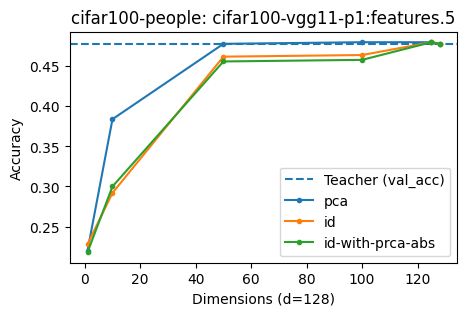

In [124]:
def viz(df):
    plt.figure(figsize=(5, 3))
    d = arr_act.shape[1]
    approaches = df.name.unique()
    plt.title(f"{DATASET_NAME}: {MODEL_NAME}:{layer}")
    plt.axhline(teacher_acc, ls="--", label="Teacher (val_acc)")
    for aix, name in enumerate(approaches):
        
        _df = df[df.name == name]
        
        plt.plot(_df.k, _df.acc, label=name, marker=".")
    plt.legend()
    plt.xlabel(f"Dimensions (d={d})")
    plt.ylabel("Accuracy")
 
viz(pd.concat([
    df_pca,
    df_id,
#     df_spectral,
#     df_prunning_lrp,
    df_id_prca_abs,

]))

# Combination of ID and PRCA

In [133]:
class NewLayer(torch.nn.Module):
    
    def __init__(self, old_layer, k):
        
        super().__init__()
        
        self.old_layer = old_layer
        self.A = torch.from_numpy(getID(k)).float().unsqueeze(2).unsqueeze(3)
        
        
    def forward(self, x):
        
        out = self.old_layer(x)
        
        out = F.conv2d(out, self.A)

        return out
        
        

def construct_pruned_model_with_id(k=50):
    student = models.get_model(MODEL_NAME)
    
    before_acc =  metrics.accuracy_with_subclasses(student, val_loader, dataset.selected_classes, dataset.transform_target, "cpu")

    print(f"Before acc={before_acc:.4f}")
    layer_ix = int(layer.split(".")[-1])
    old_layer = student.features[layer_ix]

    
    student.features[layer_ix] = NewLayer(old_layer, k)
    after_acc =  metrics.accuracy_with_subclasses(student, val_loader, dataset.selected_classes, dataset.transform_target, "cpu")

    print(f"After (k={k}) acc={after_acc:.4f}")
    
    return student


student_id_k = 64
student = construct_pruned_model_with_id(k=student_id_k)

Before acc=0.4780
Construct Interpolative Decom(k=64)
After (k=64) acc=0.4580


In [134]:
arr_student_act, arr_student_ctx = attributors.extract_activation_context(
    student, 
    layer=layer, 
    dataset=dataset, 
    data_loader=train_loader,
    logit_modifier=attributors.OneClassEvidence(dataset)
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:05<00:00,  1.42s/it]

features.5: output-dims=torch.Size([128, 8, 8])


In [135]:
torch.manual_seed(1)
stduent_basis_prcaabs = bases.PRCAAbs("prca-abs", centering=False)

stduent_basis_prcaabs.fit(arr_student_act, arr_student_ctx, mean=None)

[mode=abs,beta=0.0,device=cpu]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:26<00:00,  4.90it/s]


(array([[-0.10141473,  0.06751379, -0.00733333, ...,  0.0826342 ,
          0.07009138, -0.11956078],
        [-0.10193227,  0.06376401,  0.09568883, ...,  0.05290759,
         -0.04299936,  0.05776235],
        [-0.08610276,  0.03349943,  0.06361293, ..., -0.00049795,
         -0.00822127, -0.05363033],
        ...,
        [-0.07674588,  0.04880033, -0.03661155, ..., -0.0583536 ,
         -0.0480651 ,  0.04112437],
        [ 0.13622546, -0.04614037, -0.01979733, ...,  0.20366156,
         -0.1116342 , -0.15324724],
        [-0.07944135, -0.02443353, -0.08742142, ...,  0.01498527,
         -0.01506544, -0.01572501]], dtype=float32),
 array([ 8.11594532,  9.14522033, 10.5455394 ,  8.56727961,  7.64323385,
         4.00495245,  6.84183341,  7.05506494,  5.86501799,  5.87739713,
         5.71928287,  4.99901474,  4.3430242 ,  4.61273792,  3.55123645,
         3.70580647,  2.73473247,  2.15710448,  2.21809196,  1.72146368,
         2.0477885 ,  1.95253972,  1.76487795,  1.89381082,  1.712

In [143]:
def student_mat_A_prca(k):
    
    
    B = stduent_basis_prcaabs.artifact["eigvecs"]
#     B = basis_prcaabs.artifact["eigvecs"]

    B = B[:, :k]
    B = B @ B.T 
    return B 


In [144]:
def estimate_student_stats():
    rows = []
    for k in tqdm([1, 10, 50, 100, 125, 128]):

        acc = compute_acc(
            student,
            student_mat_A_prca(k=k)
        )

        rows.append(dict(k=k, acc=acc))

    return pd.DataFrame(rows)

df_student_stat = estimate_student_stats()

 17%|████████████████████████████▊                                                                                                                                                | 1/6 [00:01<00:08,  1.68s/it]

acc=0.1860


 33%|█████████████████████████████████████████████████████████▋                                                                                                                   | 2/6 [00:03<00:06,  1.63s/it]

acc=0.4040


 50%|██████████████████████████████████████████████████████████████████████████████████████▌                                                                                      | 3/6 [00:04<00:04,  1.56s/it]

...

acc=0.4600


 83%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                            | 5/6 [00:07<00:01,  1.51s/it]

acc=0.4600


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:09<00:00,  1.61s/it]

acc=0.4580


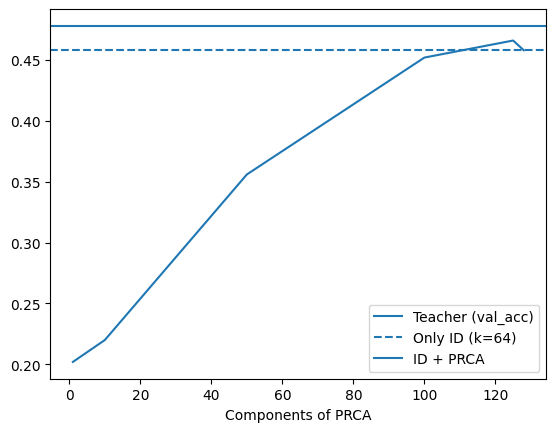

In [142]:
plt.axhline(teacher_acc, ls="-", label="Teacher (val_acc)")
plt.axhline(df_student_stat[df_student_stat.k==arr_act.shape[1]].acc.values[0], ls="--", label=f"Only ID (k={student_id_k})")
plt.plot(df_student_stat.k, df_student_stat.acc, label="ID + PRCA")
plt.xlabel("Components of PRCA")
plt.legend()

In [139]:
compute_acc(student, student_mat_A_prca(k=64))

acc=0.4520


0.4519999921321869